# 04 · Segments & Value: Where Is the Money at Risk?

Not every churner costs the same. This notebook connects churn **risk** to customer **value** to find the segments where retention spend pays back most.

1. Do churners pay more or less each month?
2. How do contract type and tenure combine?
3. Which 2-3 segments combine high churn with high revenue, and how much is at risk?
4. How do the numeric features relate to each other and to churn?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

sys.path.append(str(Path.cwd().parent))
from src.churn_utils import (load_clean, set_theme, save_fig, pct_axis, BLUE, ORANGE, GREY, INK,
                             CHURN_PALETTE, SEQ_BLUE, DIV_BLUE_RED, TENURE_BANDS, CONTRACT_ORDER)

set_theme()
df = load_clean()
overall = df["churn_flag"].mean()
df["mrr_lost"] = df["MonthlyCharges"] * df["churn_flag"]
total_mrr_lost = df["mrr_lost"].sum()
print(df.shape, f"overall churn = {overall:.1%}, MRR lost = ${total_mrr_lost:,.0f}")

(7043, 27) overall churn = 26.5%, MRR lost = $139,131


## 1. Monthly charges: churned vs retained

In [2]:
charges = df.groupby("Churn")["MonthlyCharges"].describe()[["count", "mean", "25%", "50%", "75%"]].round(2)
charges

,count,mean,25%,50%,75%
Churn,,,,,
No,5174.0,61.27,25.10,64.43,88.4
Yes,1869.0,74.44,56.15,79.65,94.2


In [3]:
churned = df.loc[df["churn_flag"] == 1, "MonthlyCharges"]
retained = df.loc[df["churn_flag"] == 0, "MonthlyCharges"]
u_stat, p_val = mannwhitneyu(churned, retained, alternative="two-sided")
rank_biserial = 2 * u_stat / (len(churned) * len(retained)) - 1
print(f"Mann-Whitney U = {u_stat:,.0f}, p = {p_val:.2e}")
print(f"Rank-biserial effect size = {rank_biserial:.3f}")
print(f"Probability a random churner pays more than a random retained customer: {u_stat / (len(churned) * len(retained)):.1%}")
print(f"Median bill: churned ${churned.median():.2f} vs retained ${retained.median():.2f}")

Mann-Whitney U = 6,003,126, p = 3.31e-54
Rank-biserial effect size = 0.242
Probability a random churner pays more than a random retained customer: 62.1%
Median bill: churned $79.65 vs retained $64.43


**In plain English:** the Mann-Whitney test compares the two groups without assuming bills are normally distributed. They are not: there is a large cluster of low-cost phone-only plans. The difference is highly significant. A randomly chosen churner pays more than a randomly chosen retained customer about 62% of the time, so churners are **disproportionately mid-to-high-bill customers**.

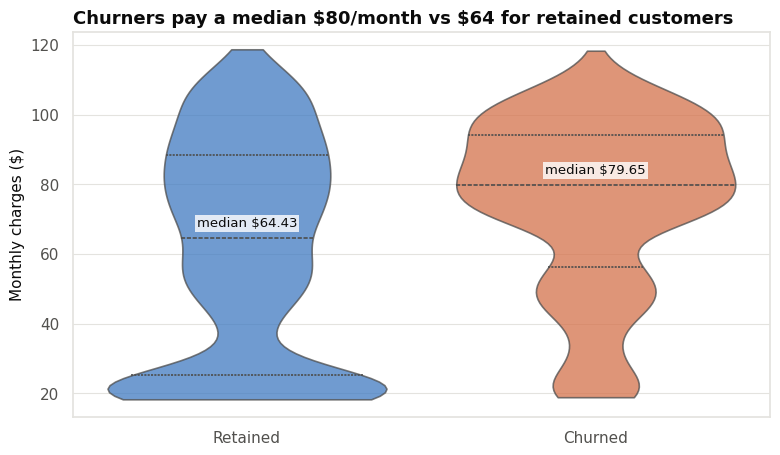

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", order=["No", "Yes"],
               palette=CHURN_PALETTE, inner="quart", cut=0, linewidth=1.2, legend=False, ax=ax)
for c in ax.collections:
    c.set_alpha(0.75)
for i, grp in enumerate(["No", "Yes"]):
    med = df.loc[df["Churn"] == grp, "MonthlyCharges"].median()
    ax.text(i, med + 2.5, f"median ${med:.2f}", ha="center", va="bottom", fontsize=9.5, color=INK,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_xticks([0, 1], ["Retained", "Churned"])
ax.set_xlabel("")
ax.set_ylabel("Monthly charges ($)")
ax.set_title(f"Churners pay a median ${churned.median():.0f}/month vs ${retained.median():.0f} for retained customers")
ax.grid(axis="x", visible=False)
save_fig(fig, "10_monthly_charges_violin")
plt.show()

## 2. Contract × tenure: churn-rate heatmap

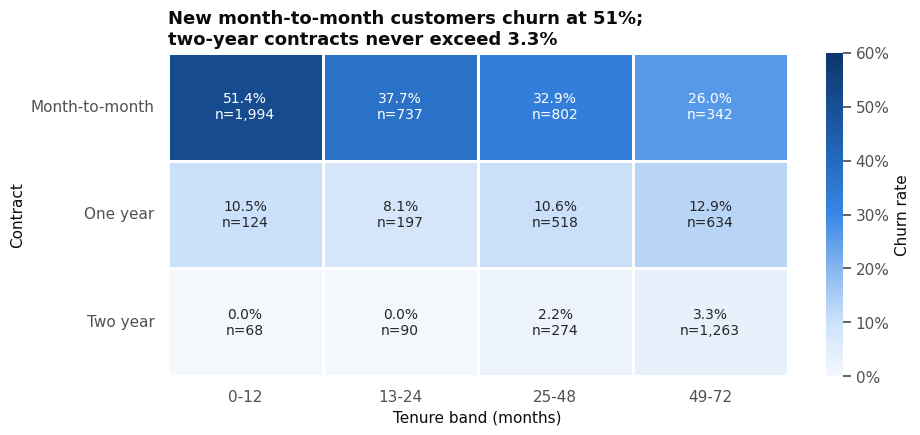

tenure_band,0-12,13-24,25-48,49-72
Contract,,,,
Month-to-month,0.514,0.377,0.329,0.260
One year,0.105,0.081,0.106,0.129
Two year,0.000,0.000,0.022,0.033


In [5]:
heat_rate = df.pivot_table(index="Contract", columns="tenure_band", values="churn_flag", aggfunc="mean", observed=True)
heat_n = df.pivot_table(index="Contract", columns="tenure_band", values="churn_flag", aggfunc="size", observed=True)
annot = heat_rate.map(lambda r: f"{r:.1%}") + "\n" + heat_n.map(lambda n: f"n={n:,}")

fig, ax = plt.subplots(figsize=(10, 4.2))
sns.heatmap(heat_rate, annot=annot, fmt="", cmap=SEQ_BLUE, vmin=0, vmax=0.6, linewidths=2, linecolor="white",
            cbar_kws={"label": "Churn rate", "format": plt.FuncFormatter(lambda x, _: f"{x:.0%}")},
            annot_kws={"fontsize": 10}, ax=ax)
ax.set_xlabel("Tenure band (months)")
ax.set_ylabel("Contract")
ax.set_title(f"New month-to-month customers churn at {heat_rate.loc['Month-to-month', '0-12']:.0%};\n"
             f"two-year contracts never exceed {heat_rate.loc['Two year'].max():.1%}")
ax.tick_params(axis="y", rotation=0)
save_fig(fig, "11_heatmap_contract_tenure")
plt.show()
heat_rate.round(3)

## 3. High-risk, high-value segments

We first scan every **contract × internet service × tenure band** combination with at least 100 customers and plot churn rate against average bill. The bubble size is the monthly revenue already lost.

In [6]:
seg_scan = (df.groupby(["Contract", "InternetService", "tenure_band"], observed=True)
              .agg(customers=("churn_flag", "size"), churn_rate=("churn_flag", "mean"),
                   avg_bill=("MonthlyCharges", "mean"), mrr_lost=("mrr_lost", "sum"))
              .query("customers >= 100")
              .sort_values("mrr_lost", ascending=False))
seg_scan["share_of_mrr_lost"] = seg_scan["mrr_lost"] / total_mrr_lost
seg_scan.head(10).round(3)

customers  churn_rate  avg_bill  \
Contract       InternetService tenure_band                                    
Month-to-month Fiber optic     0-12               916       0.702    82.078   
                               25-48              521       0.434    91.239   
                               13-24              425       0.506    87.541   
               DSL             0-12               690       0.425    47.884   
               Fiber optic     49-72              266       0.293    94.953   
One year       Fiber optic     49-72              355       0.189   100.489   
                               25-48              154       0.201    96.044   
Two year       Fiber optic     49-72              393       0.071   104.827   
Month-to-month DSL             13-24              232       0.237    52.681   
               No              0-12               388       0.227    20.267   

                                            mrr_lost  share_of_mrr_lost  
Contract       InternetService tenure_band                               
Month-to-month Fiber optic     0-12         53178.30              0.382  
                               25-48        20762.05              0.149  
                               13-24        19046.90              0.137  
               DSL             0-12         13351.90              0.096  
               Fiber optic     49-72         7494.75              0.054  
One year       Fiber optic     49-72         6926.20              0.050  
                               25-48         3039.10              0.022  
Two year       Fiber optic     49-72         2965.55              0.021  
Month-to-month DSL             13-24         2765.40              0.020  
               No              0-12          1771.25              0.013

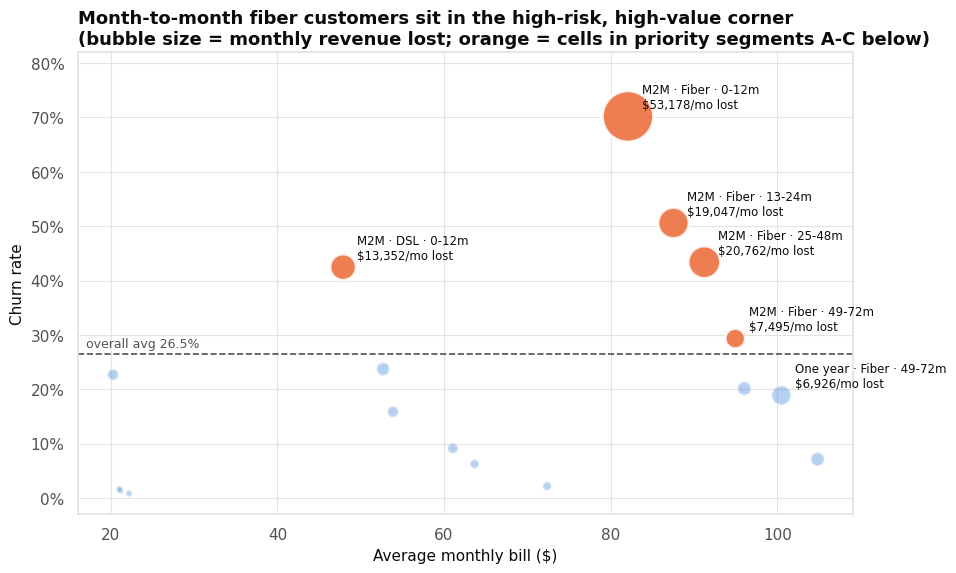

In [7]:
def label(idx):
    c, i, t = idx
    return f"{c.replace('Month-to-month', 'M2M')} · {i.replace('Fiber optic', 'Fiber')} · {t}m"

def is_priority(idx):
    c, i, t = idx
    return c == "Month-to-month" and (i == "Fiber optic" or (i == "DSL" and t == "0-12"))

fig, ax = plt.subplots(figsize=(10, 6))
is_top = np.array([is_priority(i) for i in seg_scan.index])
for mask, color, alpha in [(~is_top, BLUE, 0.35), (is_top, ORANGE, 0.85)]:
    sub = seg_scan[mask]
    ax.scatter(sub["avg_bill"], sub["churn_rate"], s=sub["mrr_lost"] / 40 + 20, color=color, alpha=alpha,
               edgecolor="white", linewidth=2)
for idx, r in seg_scan.iterrows():
    if r["mrr_lost"] >= 5000:
        ax.annotate(f"{label(idx)}\n${r['mrr_lost']:,.0f}/mo lost", (r["avg_bill"], r["churn_rate"]),
                    xytext=(10, 6), textcoords="offset points", fontsize=8.5, color=INK)
ax.axhline(overall, color=GREY, ls="--", lw=1.2)
ax.text(ax.get_xlim()[0] + 1, overall + 0.012, f"overall avg {overall:.1%}", color=GREY, fontsize=9)
pct_axis(ax, "y")
ax.set_ylim(-0.03, 0.82)
ax.set_xlabel("Average monthly bill ($)")
ax.set_ylabel("Churn rate")
ax.set_title("Month-to-month fiber customers sit in the high-risk, high-value corner\n(bubble size = monthly revenue lost; orange = cells in priority segments A-C below)")
save_fig(fig, "12_segment_risk_value_map")
plt.show()

### Priority segments

The scan points to three **mutually exclusive** segments, so their revenue can be added up without double counting:

| Segment | Definition | Why it matters |
|---|---|---|
| **A. New fiber, no contract** | Month-to-month · Fiber optic · tenure ≤ 12 months | Highest churn rate of any sizeable group |
| **B. Established fiber, no contract** | Month-to-month · Fiber optic · tenure 13+ months | Highest bill, still well above-average churn |
| **C. New DSL, no contract** | Month-to-month · DSL · tenure ≤ 12 months | Next-largest new-customer leak |

**Revenue measures (per segment):**
- *Annualised revenue lost* = churners' monthly charges × 12. This is the observed loss.
- *Revenue still exposed* = the retained customers' monthly charges × 12. This is the revenue that could be lost next if nothing changes.
- *Expected further annual loss* = revenue still exposed × the segment's churn rate. This assumes the observed churn rate repeats.

In [8]:
m2m = df["Contract"] == "Month-to-month"
new = df["tenure"] <= 12
segments = {
    "A. New fiber, month-to-month": m2m & (df["InternetService"] == "Fiber optic") & new,
    "B. Established fiber, month-to-month": m2m & (df["InternetService"] == "Fiber optic") & ~new,
    "C. New DSL, month-to-month": m2m & (df["InternetService"] == "DSL") & new,
}
assert not any((segments[a] & segments[b]).any() for a in segments for b in segments if a < b), "segments overlap"

rows = []
for name, mask in segments.items():
    s = df[mask]
    retained_mrr = s.loc[s["churn_flag"] == 0, "MonthlyCharges"].sum()
    rows.append({
        "segment": name,
        "customers": len(s),
        "share_of_base": len(s) / len(df),
        "churned": int(s["churn_flag"].sum()),
        "churn_rate": s["churn_flag"].mean(),
        "avg_bill": s["MonthlyCharges"].mean(),
        "mrr_lost": s["mrr_lost"].sum(),
        "annual_revenue_lost": s["mrr_lost"].sum() * 12,
        "share_of_total_mrr_lost": s["mrr_lost"].sum() / total_mrr_lost,
        "retained_customers": int((s["churn_flag"] == 0).sum()),
        "annual_revenue_still_exposed": retained_mrr * 12,
        "expected_further_annual_loss": retained_mrr * 12 * s["churn_flag"].mean(),
        "pct_no_tech_support": (s["TechSupport"] == "No").mean(),
        "pct_electronic_check": (s["PaymentMethod"] == "Electronic check").mean(),
    })
seg = pd.DataFrame(rows).set_index("segment")
totals = seg[["customers", "churned", "mrr_lost", "annual_revenue_lost", "retained_customers",
              "annual_revenue_still_exposed", "expected_further_annual_loss"]].sum()
totals = totals.round(0).astype(int)
print(f"Three segments = {totals['customers']:,} customers ({totals['customers'] / len(df):.1%} of base), "
      f"{totals['churned']:,} churners ({totals['churned'] / df['churn_flag'].sum():.1%} of all churners), "
      f"${totals['mrr_lost']:,.0f} MRR lost ({totals['mrr_lost'] / total_mrr_lost:.1%} of total), "
      f"${totals['annual_revenue_lost']:,.0f} annualised.")
print(f"Revenue still exposed: ${totals['annual_revenue_still_exposed']:,.0f}/yr; "
      f"expected further loss at current rates: ${totals['expected_further_annual_loss']:,.0f}/yr")

fmt = {"share_of_base": "{:.1%}", "churn_rate": "{:.1%}", "share_of_total_mrr_lost": "{:.1%}",
       "pct_no_tech_support": "{:.0%}", "pct_electronic_check": "{:.0%}", "avg_bill": "${:,.2f}",
       "mrr_lost": "${:,.0f}", "annual_revenue_lost": "${:,.0f}", "annual_revenue_still_exposed": "${:,.0f}",
       "expected_further_annual_loss": "${:,.0f}"}
seg_display = seg.copy()
for c, f in fmt.items():
    seg_display[c] = seg_display[c].map(f.format)
seg_display.T

Three segments = 2,818 customers (40.0% of base), 1,455 churners (77.8% of all churners), $113,834 MRR lost (81.8% of total), $1,366,007 annualised.
Revenue still exposed: $1,252,643/yr; expected further loss at current rates: $607,843/yr


segment,"A. New fiber, month-to-month","B. Established fiber, month-to-month","C. New DSL, month-to-month"
customers,916,1212,690
share_of_base,13.0%,17.2%,9.8%
churned,643,519,293
churn_rate,70.2%,42.8%,42.5%
avg_bill,$82.08,$90.76,$47.88
mrr_lost,"$53,178","$47,304","$13,352"
annual_revenue_lost,"$638,140","$567,644","$160,223"
share_of_total_mrr_lost,38.2%,34.0%,9.6%
retained_customers,273,693,397
annual_revenue_still_exposed,"$264,058","$752,331","$236,254"


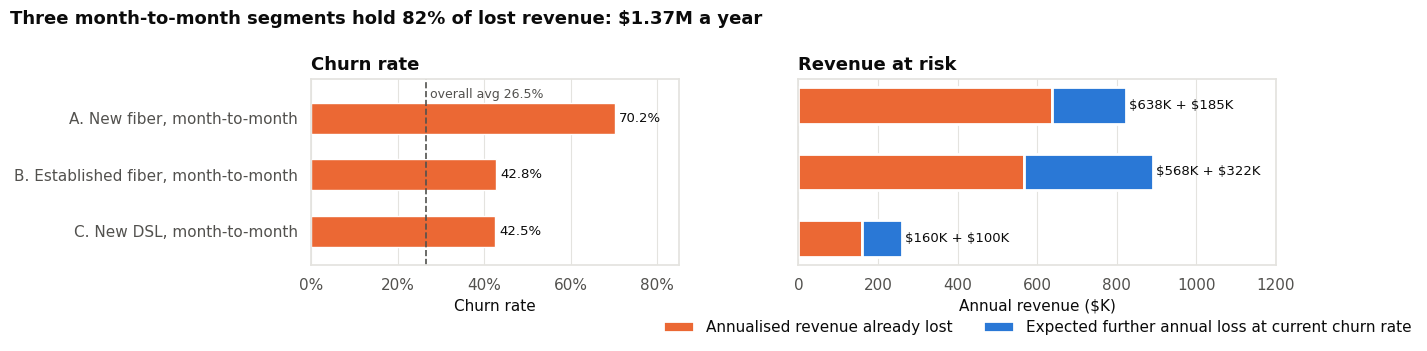

In [9]:
seg.to_csv(Path.cwd().parent / "data" / "processed" / "priority_segments.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1, 1.3]})
names = seg.index[::-1]
ax = axes[0]
ax.barh(names, seg.loc[names, "churn_rate"], color=ORANGE, height=0.55)
ax.axvline(overall, color=GREY, ls="--", lw=1.2)
ax.text(overall, 2.42, f" overall avg {overall:.1%}", color=GREY, fontsize=9, va="center")
for i, r in enumerate(seg.loc[names, "churn_rate"]):
    ax.text(r + 0.01, i, f"{r:.1%}", va="center", fontsize=9.5)
ax.set_xlim(0, 0.85)
ax.set_ylim(-0.6, 2.7)
pct_axis(ax, "x")
ax.set_xlabel("Churn rate")
ax.set_title("Churn rate")
ax.grid(axis="y", visible=False)

ax = axes[1]
lost = seg.loc[names, "annual_revenue_lost"] / 1000
exposed = seg.loc[names, "expected_further_annual_loss"] / 1000
ax.barh(names, lost, color=ORANGE, height=0.55, label="Annualised revenue already lost", edgecolor="white", linewidth=2)
ax.barh(names, exposed, left=lost, color=BLUE, height=0.55, label="Expected further annual loss at current churn rate",
        edgecolor="white", linewidth=2)
for i, (l, e) in enumerate(zip(lost, exposed)):
    ax.text(l + e + 8, i, f"${l:,.0f}K + ${e:,.0f}K", va="center", fontsize=9.5)
ax.set_yticks([])
ax.set_xlim(0, (lost + exposed).max() * 1.35)
ax.set_xlabel("Annual revenue ($K)")
ax.set_title("Revenue at risk")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
ax.grid(axis="y", visible=False)
fig.suptitle(f"Three month-to-month segments hold {totals['mrr_lost'] / total_mrr_lost:.0%} of lost revenue: "
             f"${totals['annual_revenue_lost'] / 1e6:.2f}M a year",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "13_priority_segments_revenue")
plt.show()

## 4. Correlation of numeric features

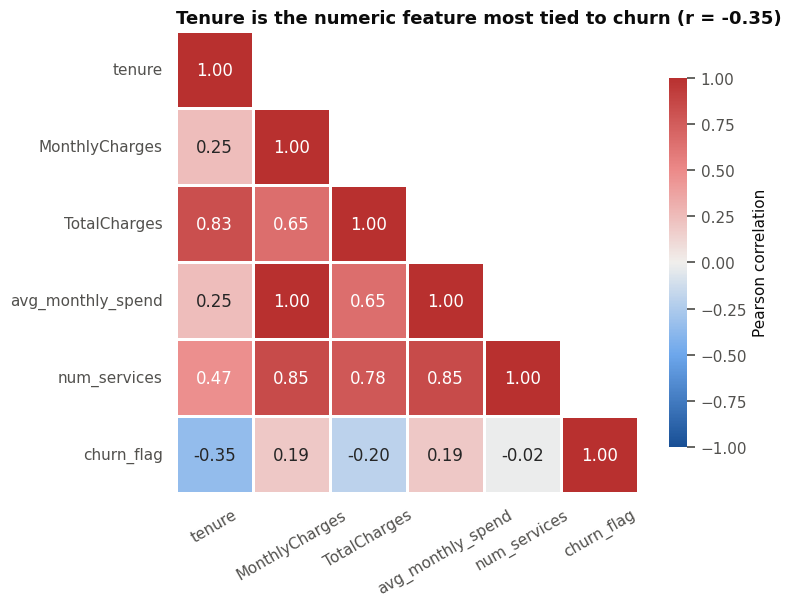

tenure              -0.352
TotalCharges        -0.198
num_services        -0.019
avg_monthly_spend    0.193
MonthlyCharges       0.193
Name: churn_flag, dtype: float64

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend", "num_services", "churn_flag"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIV_BLUE_RED, vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor="white", square=True, cbar_kws={"label": "Pearson correlation", "shrink": 0.8}, ax=ax)
ax.grid(False)
ax.set_title(f"Tenure is the numeric feature most tied to churn (r = {corr.loc['tenure', 'churn_flag']:.2f})")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
save_fig(fig, "14_correlation_heatmap")
plt.show()
corr["churn_flag"].drop("churn_flag").sort_values().round(3)

Note: `TotalCharges` is roughly tenure × monthly charge, so it correlates strongly with both. `avg_monthly_spend` is nearly identical to `MonthlyCharges`. These redundant pairs are dropped before modelling to avoid multicollinearity.

## Key Takeaways

- **Churners pay more:** their median bill is **$79.65 vs $64.43** for retained customers (Mann-Whitney p = 3.3e-54). A randomly chosen churner out-pays a randomly chosen retained customer **62%** of the time, so churn removes above-average revenue.
- **Contract × tenure:** new month-to-month customers (0-12 months) churn at **51.4%**. Even month-to-month customers with 4+ years of tenure churn at 26.0%, while **two-year contracts never exceed 3.3%** at any tenure.
- **Three mutually exclusive month-to-month segments account for 81.8% of all lost MRR** ($113,834 of $139,131, or **$1.37M a year**), while making up only 40.0% of customers:
  - **A. New fiber (≤12 months):** 916 customers, **70.2% churn**, $82.08 average bill, **$638K/yr lost**. 91% have no tech support and 69% pay by electronic check.
  - **B. Established fiber (13+ months):** 1,212 customers, **42.8% churn**, the highest average bill ($90.76), **$568K/yr lost**. Its 693 remaining customers bill $752K a year, and **$322K/yr** more would be lost if the churn rate holds.
  - **C. New DSL (≤12 months):** 690 customers, **42.5% churn**, **$160K/yr lost**.
- **Still exposed:** the 1,363 customers who remain in these segments bill **$1.25M a year**. At current churn rates, a further **$608K/yr** is expected to walk out.
- **Correlations:** tenure has the strongest numeric link to churn (**r = -0.35**). `MonthlyCharges` and `avg_monthly_spend` are effectively the same variable (r = 1.00), and `TotalCharges` largely reflects tenure (r = 0.83), so the model in notebook 05 uses only one of each pair.